# Freight Rate Prediction

**Goal:** predict `posted_rate` for the 12,000 loads in `validation.csv` (Nov–Dec 2025) and for 31 fixed December
chart rows, using only the labeled Jan–Oct 2025 data in `train_test.csv`.

**Pipeline in one picture**

1. Load data → 2. Audit data quality → 3. Explore → 4. Handle label outliers → 5. Choose a *time-based* validation
scheme → 6. Compare models with cross-validation → 7. Tune lightly → 8. Fit final model on all labeled data →
9. Predict validation + December → 10. Sanity-check and run `score.py`.

Every code line below has a comment saying what it does; every step starts with a short note on **why**.

### 0. Setup
**Why:** import the libraries once, fix the random seed so results are reproducible, and point at the data folder.

In [7]:
!unzip -q -o freight-rate-challenge.zip
%cd freight-rate-challenge
!ls

/content/freight-rate-challenge
data		      README.md		scorer_results
environment.yml       report		setup_env.bat
features.py	      requirements.txt	setup_env.sh
figures		      results		validation_predictions.csv
model.ipynb	      run_pipeline.py
README_assessment.md  score.py


In [8]:
import sys, subprocess, warnings                 # sys/subprocess: run score.py at the end; warnings: silence noise
from pathlib import Path                         # clean file-path handling
import numpy as np                               # numeric arrays and maths
import pandas as pd                              # tables (DataFrames)
import matplotlib.pyplot as plt                  # plotting
import lightgbm as lgb                           # gradient-boosted trees (our model)
from IPython.display import Image, display       # show saved PNGs inside the notebook

from features import FeatureBuilder, drop_label_outliers   # our own cleaning + feature code (features.py)

warnings.filterwarnings("ignore")                # hide harmless library warnings
SEED = 42                                        # one seed used everywhere -> reproducible
DATA = Path("data")                              # folder holding the CSV files
FIG = Path("figures"); FIG.mkdir(exist_ok=True)  # folder for charts (created if missing)
RES = Path("results"); RES.mkdir(exist_ok=True)  # folder for result tables
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})  # tidy plot style

## 1. Load the data
**Why:** `parse_dates` turns the `date` text into real dates so we can split and group by time.

In [9]:
train = pd.read_csv(DATA / "train_test.csv", parse_dates=["date"])        # 48,000 labeled loads (has posted_rate)
val = pd.read_csv(DATA / "validation.csv", parse_dates=["date"])          # 12,000 loads to predict (no posted_rate)
dec = pd.read_csv(DATA / "december_chart_inputs.csv")                     # 31 fixed December chart rows
template = pd.read_csv(DATA / "validation_predictions_template.csv")      # required load_id order for the answer file

print("train", train.shape, "| validation", val.shape, "| december", dec.shape)   # sizes of each table
print(list(train.columns))                                                # column names
train.head(3)                                                             # first 3 rows

train (48000, 14) | validation (12000, 13) | december (31, 7)
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54


## 2. Data-quality audit
**Why:** before modelling, measure exactly what is wrong in *both* train and validation. Anything wrong in validation
must be **fixed**, not dropped, because we owe a prediction for all 12,000 loads.

In [10]:
def audit(df, name):                                                      # build one column of facts about a dataset
    return pd.Series({
        "rows": len(df),                                                  # number of rows
        "first_date": df["date"].min().date(),                            # earliest date
        "last_date": df["date"].max().date(),                             # latest date
        "missing_weight": int(df["weight"].isna().sum()),                 # empty weight cells
        "negative_weight": int((df["weight"] < 0).sum()),                 # impossible negative weights
        "missing_market_index": int(df["market_index"].isna().sum()),     # empty market_index cells
        "missing_quote_signal": int(df["quote_signal"].isna().sum()),     # empty quote_signal cells
        "duplicate_load_id": int(df["load_id"].duplicated().sum()),       # repeated ids
        "duplicate_rows_ignoring_id": int(df.drop(columns="load_id").duplicated().sum()),  # repeated loads
        "pickup_equals_delivery": int((df["pickup"] == df["delivery"]).sum()),             # nonsensical routes
    }, name=name)

report = pd.concat([audit(train, "train"), audit(val, "validation")], axis=1)   # side-by-side table
report.to_csv(RES / "data_quality_audit.csv")                                   # save for the report
display(report)

seen = set(train["pickup"]) | set(train["delivery"])                            # every city that appears in train
new_cities = (set(val["pickup"]) | set(val["delivery"])) - seen                 # cities only validation has
print("Cities in validation but never in train:", sorted(new_cities))
lane_key = lambda d: d["pickup"] + ">" + d["delivery"]                          # a lane = origin>destination
unseen_lane = ~lane_key(val).isin(set(lane_key(train)))                         # validation loads on lanes train never saw
print(f"Validation rows on lanes never seen in train: {unseen_lane.mean():.1%}  <- feature fallbacks must be safe")
print("Equipment values:", train["equipment"].unique(), "| validation:", val["equipment"].unique())

,train,validation
rows,48000,12000
first_date,2025-01-01,2025-11-01
last_date,2025-10-31,2025-12-31
missing_weight,300,165
negative_weight,292,145
missing_market_index,374,249
missing_quote_signal,0,0
duplicate_load_id,0,0
duplicate_rows_ignoring_id,0,0
pickup_equals_delivery,0,0


Cities in validation but never in train: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
Validation rows on lanes never seen in train: 12.2%  <- feature fallbacks must be safe
Equipment values: ['Dry Van' 'Reefer' 'Flatbed'] | validation: ['Flatbed' 'Reefer' 'Dry Van']


## 3. Exploration
**Why:** find what drives the rate, so features and the validation plan match reality.
We look at (a) rate per mile over time next to `market_index`, (b) rate vs distance by equipment.

           rpm  market_index  loads
date                               
2025-01  2.029         0.927   4918
2025-02  2.061         0.996   4337
2025-03  2.139         1.073   5036
2025-04  2.147         1.208   4819
2025-05  2.190         1.301   4913
2025-06  2.248         1.280   4783
2025-07  2.187         1.201   4912
2025-08  2.121         0.981   4759
2025-09  2.160         0.893   4670
2025-10  2.164         0.958   4853
validation market_index by month: {Period('2025-11', 'M'): 0.919, Period('2025-12', 'M'): 0.935}

Correlation of rate with distance: 0.909
Median rate/mile by equipment:
 equipment
Dry Van    2.046
Flatbed    2.220
Reefer     2.312
Name: rpm, dtype: float64


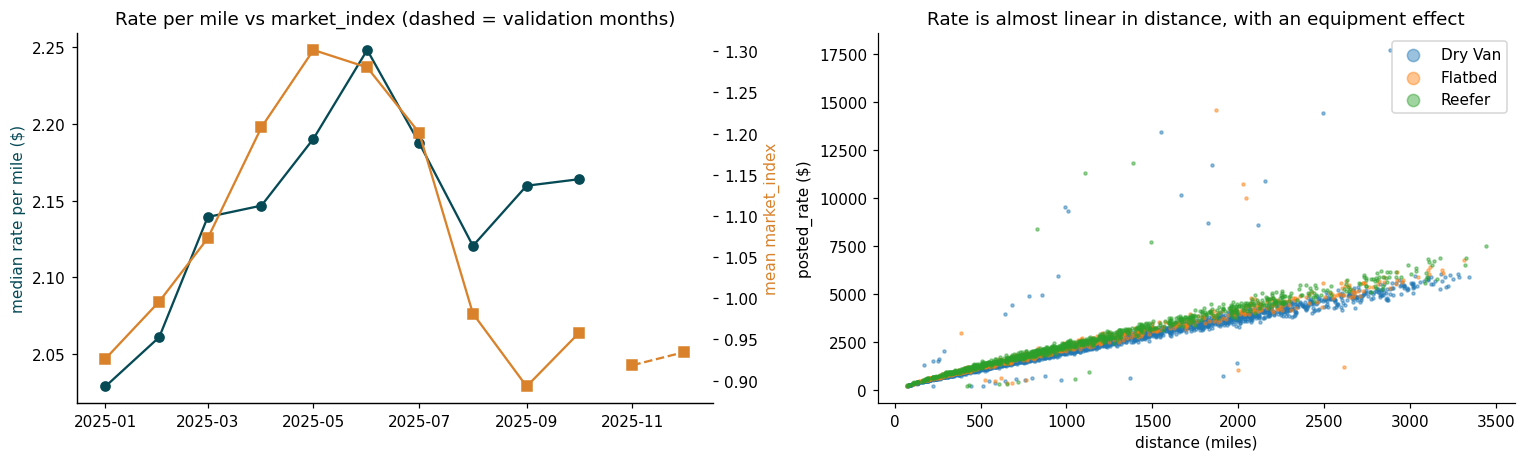

In [11]:
eda = train.assign(rpm=train["posted_rate"] / train["distance"])          # add rate-per-mile (a copy; train untouched)
monthly = eda.groupby(eda["date"].dt.to_period("M")).agg(                 # one row per month
    rpm=("rpm", "median"), market_index=("market_index", "mean"), loads=("rpm", "size"))
val_mi = val.groupby(val["date"].dt.to_period("M"))["market_index"].mean()   # validation market_index by month
print(monthly.round(3))
print("validation market_index by month:", val_mi.round(3).to_dict())
print("\nCorrelation of rate with distance:", round(train["posted_rate"].corr(train["distance"]), 3))
print("Median rate/mile by equipment:\n", eda.groupby("equipment")["rpm"].median().round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))                           # two charts side by side
m = monthly.index.to_timestamp()                                          # month start dates for the x-axis
ax[0].plot(m, monthly["rpm"], marker="o", color="#064A56")                # median rate per mile by month
ax[0].set_ylabel("median rate per mile ($)", color="#064A56")
tw = ax[0].twinx()                                                        # second y-axis for market_index
tw.plot(m, monthly["market_index"], marker="s", color="#D9822B")          # train market_index by month
vm = val_mi.index.to_timestamp()
tw.plot(vm, val_mi.values, marker="s", ls="--", color="#D9822B")          # validation market_index (dashed)
tw.set_ylabel("mean market_index", color="#D9822B")
ax[0].set_title("Rate per mile vs market_index (dashed = validation months)")
samp = eda.sample(4000, random_state=SEED)                                # sample so the scatter stays readable
for eq, g in samp.groupby("equipment"):                                   # one colour per equipment type
    ax[1].scatter(g["distance"], g["posted_rate"], s=4, alpha=.45, label=eq)
ax[1].set_xlabel("distance (miles)"); ax[1].set_ylabel("posted_rate ($)")
ax[1].set_title("Rate is almost linear in distance, with an equipment effect"); ax[1].legend(markerscale=4)
plt.tight_layout(); plt.savefig(FIG / "eda_overview.png"); plt.show()    # save for the report, then display

## 4. Label outliers (train only)
**Why:** a handful of loads have rates that are impossible for their distance/equipment/month. They are *label noise*,
and they would pull the model toward wrong values.
We compare each load's rate-per-mile with the median for the same equipment and month. If the data were healthy we
would see one bell; instead there are two extra clumps far away from 1.0.

rpm
<0.5x                  333
0.5-0.7x                 4
0.7-1.5x (normal)    47306
1.5-2x                  18
>2x                    339
Name: count, dtype: int64


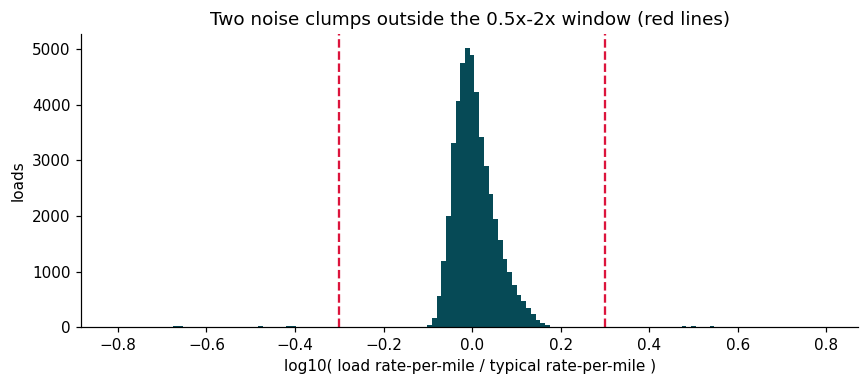

[outliers] dropped 672 of 48000 train rows (1.40%)


In [12]:
ratio = (eda["rpm"] / eda.groupby(["equipment", eda["date"].dt.to_period("M")])["rpm"].transform("median"))  # 1.0 = typical
bands = pd.cut(ratio, [0, .5, .7, 1.5, 2, 100], labels=["<0.5x", "0.5-0.7x", "0.7-1.5x (normal)", "1.5-2x", ">2x"])
print(bands.value_counts().sort_index())                                  # how many rows fall in each band

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(np.log10(ratio), bins=150, color="#064A56")                       # histogram on a log scale
for t in (0.5, 2.0):                                                      # our keep-window edges
    ax.axvline(np.log10(t), color="crimson", ls="--")
ax.set_xlabel("log10( load rate-per-mile / typical rate-per-mile )"); ax.set_ylabel("loads")
ax.set_title("Two noise clumps outside the 0.5x-2x window (red lines)")
plt.tight_layout(); plt.savefig(FIG / "outliers.png"); plt.show()

train_clean = drop_label_outliers(train)                                  # drop outliers from TRAIN only

## 5. Validation strategy (the most important decision)
**Why time-based, not random?** The final task is *forecasting*: train on Jan–Oct, predict Nov–Dec. A random split puts
loads from the same days in both train and test, so the model can lean on date-specific information it will never have
in real use and the score looks better than it should. So we mimic the real task with an **expanding-window** split:

| Fold | Train on | Evaluate on |
|---|---|---|
| 1 | Jan – Jun | Jul – Aug |
| 2 | Jan – Jul | Aug – Sep |
| 3 | Jan – Aug | Sep – Oct |

Rules that keep it honest: outlier-dropping, imputation values, the baseline line and city/lane effects are all
**fit on the training window only**; the holdout is **never** cleaned of outliers for the *official* score
(we also print a "clean holdout" number purely as a diagnostic).

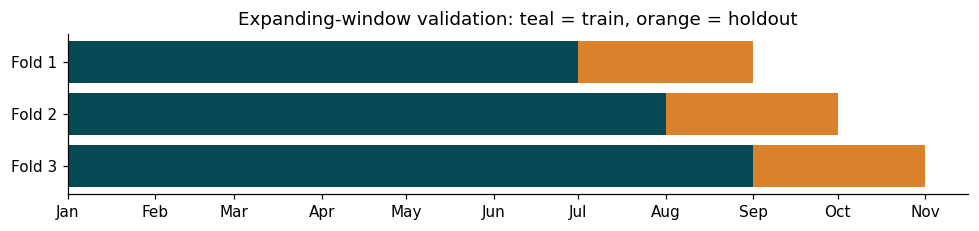

['28408 train / 9671 holdout', '33255 train / 9429 holdout', '37947 train / 9523 holdout']


In [13]:
FOLDS = [("2025-07-01", "2025-09-01"), ("2025-08-01", "2025-10-01"), ("2025-09-01", "2025-11-01")]  # (holdout start, holdout end)

fig, ax = plt.subplots(figsize=(9, 2.2))                                  # picture of the split for the report
for i, (s, e) in enumerate(FOLDS):
    s_, e_ = pd.Timestamp(s), pd.Timestamp(e)
    ax.barh(i, (s_ - pd.Timestamp("2025-01-01")).days, left=pd.Timestamp("2025-01-01").toordinal(), color="#064A56")
    ax.barh(i, (e_ - s_).days, left=s_.toordinal(), color="#D9822B")
ax.set_yticks(range(3)); ax.set_yticklabels([f"Fold {i+1}" for i in range(3)])
ax.set_xticks([pd.Timestamp(f"2025-{m:02d}-01").toordinal() for m in range(1, 12)])
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov"])
ax.set_title("Expanding-window validation: teal = train, orange = holdout"); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIG / "split_strategy.png"); plt.show()

def believable(h):                                                        # diagnostic mask: rows that are not label outliers
    r = h["posted_rate"] / h["distance"]                                  # rate per mile of holdout rows
    t = r.groupby([h["equipment"], h["date"].dt.to_period("M")]).transform("median")   # their month's typical value
    return ((r / t > .5) & (r / t < 2.0)).to_numpy()

def make_fold(fit, hold, include_market=False):                           # build features for one train/holdout pair
    fit = drop_label_outliers(fit, verbose=False).reset_index(drop=True)  # outliers removed from TRAIN window only
    fb = FeatureBuilder(include_market=include_market, seed=SEED)         # fresh feature builder (learns nothing yet)
    Xf = fb.fit_transform(fit)                                            # learn from the train window, build its features
    Xh = fb.transform(hold)                                               # apply what was learned to the holdout
    return {"fit": fit, "hold": hold.reset_index(drop=True), "Xf": Xf, "Xh": Xh, "ok": believable(hold)}

def time_folds(include_market=False):                                     # build all three time-based folds
    out = []
    for s, e in FOLDS:
        fit = train[train["date"] < s]                                    # everything BEFORE the holdout starts
        hold = train[(train["date"] >= s) & (train["date"] < e)]          # the next two months
        out.append(make_fold(fit, hold, include_market))
    return out

D = time_folds()                                                          # default features (no market_index)
DM = time_folds(include_market=True)                                      # same folds incl. market_index features
print([f"{len(d['fit'])} train / {len(d['hold'])} holdout" for d in D])

## 6. Candidate models
**Why this ladder?** Start with trivial baselines so we know what "good" means, then add complexity only if it earns it.

1. **Naive:** median rate-per-mile × distance.
2. **Linear baseline:** `log(rate) ~ log(distance)` fitted separately per equipment (already inside `features.py`).
3. **Linear + weight:** adds weight (weight turned out to matter once distance is accounted for).
4. **LightGBM on the baseline's residual:** the line handles the big, extrapolatable distance effect; trees learn the
   small leftovers (weight, quote_signal, cities, calendar). *Boosting the residual* matters because trees cannot
   extrapolate beyond what they saw, but a line can.
5. Variants: without `quote_signal`, and with `market_index` features.

**Metric:** MAE ($) and MAPE (%) — we don't know which one Spotter uses, so we report both. We train with an L1
(absolute-error) loss on log-rate, which targets the *median* and is robust to leftover noisy labels.

In [14]:
BASE = dict(objective="l1", n_estimators=300, learning_rate=0.03, num_leaves=5, min_child_samples=60,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1)   # LightGBM settings (tuned in section 7)

def metrics(pred, actual, ok):                                            # score predictions in dollars and percent
    err = np.abs(pred - actual); pct = err / actual * 100                 # absolute error, percentage error
    return {"raw_MAE": err.mean(), "raw_MAPE": pct.mean(),                # official-style score (all holdout rows)
            "clean_MAE": err[ok].mean(), "clean_MAPE": pct[ok].mean()}    # diagnostic score (outlier rows excluded)

def predict_lgbm(f, params=None, drop=(), seeds=(SEED,)):                 # train on a fold's train window, predict holdout
    cols = [c for c in f["Xf"].columns if c not in drop]                  # which features to use
    y = np.log(f["fit"]["posted_rate"].to_numpy()) - f["Xf"]["baseline_log_rate"].to_numpy()   # target = what the line missed
    logs = []
    for s in seeds:                                                       # (several seeds are averaged for stability)
        m = lgb.LGBMRegressor(**{**BASE, **(params or {}), "random_state": s}).fit(f["Xf"][cols], y)
        logs.append(m.predict(f["Xh"][cols]))                             # predicted residual on the holdout
    return np.exp(np.mean(logs, axis=0) + f["Xh"]["baseline_log_rate"].to_numpy())   # line + residual, back to dollars

def cv(name, data, kind="lgbm", **kw):                                    # average a model's score over the 3 folds
    rows = []
    for f in data:
        actual = f["hold"]["posted_rate"].to_numpy()
        if kind == "naive":                                               # median rate/mile x distance
            pred = (f["fit"]["posted_rate"] / f["fit"]["distance"]).median() * f["hold"]["distance"].to_numpy()
        elif kind == "linear":                                            # distance x equipment line only
            pred = np.exp(f["Xh"]["baseline_log_rate"].to_numpy())
        elif kind == "linear+weight":                                     # line + a linear weight correction
            A = lambda X: np.column_stack([np.ones(len(X)), X["weight_k"]])
            y = np.log(f["fit"]["posted_rate"].to_numpy()) - f["Xf"]["baseline_log_rate"].to_numpy()
            b, *_ = np.linalg.lstsq(A(f["Xf"]), y, rcond=None)            # fit the weight slope on train window only
            pred = np.exp(A(f["Xh"]) @ b + f["Xh"]["baseline_log_rate"].to_numpy())
        else:                                                             # LightGBM on the residual
            pred = predict_lgbm(f, **kw)
        rows.append(metrics(pred, actual, f["ok"]))
    return pd.Series(pd.DataFrame(rows).mean(), name=name)                # mean over folds

results = pd.concat([
    cv("1 naive: median rate/mile x distance", D, "naive"),
    cv("2 linear: distance x equipment", D, "linear"),
    cv("3 linear + weight", D, "linear+weight"),
    cv("4 LightGBM on residual (FINAL)", D),
    cv("5a  same, without quote_signal", D, drop=("quote_signal",)),
    cv("5b  same, WITH market_index features", DM),
], axis=1).T.round(2)
results.to_csv(RES / "cv_results.csv")                                    # saved for the report
display(results)

,raw_MAE,raw_MAPE,clean_MAE,clean_MAPE
1 naive: median rate/mile x distance,255.74,11.42,205.57,9.23
2 linear: distance x equipment,131.85,5.87,79.47,3.56
3 linear + weight,116.98,5.28,64.45,2.96
4 LightGBM on residual (FINAL),102.61,4.40,49.99,2.08
"5a same, without quote_signal",102.79,4.44,50.16,2.12
"5b same, WITH market_index features",140.58,5.96,88.44,3.74


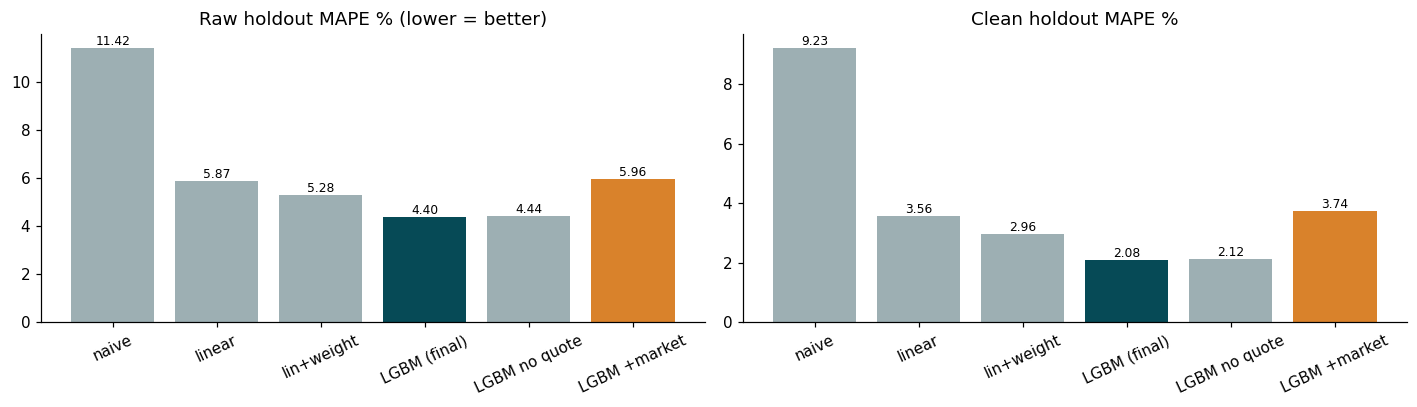

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))                           # bar chart of the results table
short = ["naive", "linear", "lin+weight", "LGBM (final)", "LGBM no quote", "LGBM +market"]
for a, col, ttl in zip(ax, ["raw_MAPE", "clean_MAPE"], ["Raw holdout MAPE % (lower = better)", "Clean holdout MAPE %"]):
    a.bar(short, results[col], color=["#9DAFB3"] * 3 + ["#064A56", "#9DAFB3", "#D9822B"])
    a.set_title(ttl); a.tick_params(axis="x", rotation=25)
    for i, v in enumerate(results[col]): a.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "cv_comparison.png"); plt.show()

### Why a random split would have fooled us
**Why:** to *prove* the time-based split matters, score the same two models on a random 80/20 split of all labeled data.
If the market_index model looks much better there than on the time split, that gap is leakage/over-optimism.

In [16]:
rng = train.sample(frac=1.0, random_state=SEED)                           # shuffle all rows
cut = int(len(rng) * 0.8)                                                 # 80% train / 20% test
rand_fit, rand_hold = rng.iloc[:cut], rng.iloc[cut:]                      # random split ignoring time
rows = []
for name, inc in [("LGBM without market_index", False), ("LGBM with market_index", True)]:
    f = make_fold(rand_fit, rand_hold, include_market=inc)                # same code path, random split
    p = predict_lgbm(f)
    rows.append({"model": name, "split": "random 80/20", **metrics(p, f["hold"]["posted_rate"].to_numpy(), f["ok"])})
    t = cv(name, DM if inc else D)                                        # same model on the time-based folds
    rows.append({"model": name, "split": "time-based (3 folds)", **t.to_dict()})
leak = pd.DataFrame(rows).round(2)
leak.to_csv(RES / "random_vs_time_split.csv", index=False)
display(leak[["model", "split", "raw_MAPE", "clean_MAPE"]])

,model,split,raw_MAPE,clean_MAPE
0,LGBM without market_index,random 80/20,4.90,2.59
1,LGBM without market_index,time-based (3 folds),4.40,2.08
2,LGBM with market_index,random 80/20,4.23,1.92
3,LGBM with market_index,time-based (3 folds),5.96,3.74


## 7. Light hyper-parameter tuning
**Why:** small grid, scored with the same time-based folds. Earlier experiments showed *simpler* is better here (the
signal is mostly linear), so we only search small trees and a moderate number of rounds.
We pick by **raw MAE** (the realistic all-rows score), then check the choice is stable in the other metrics.

In [17]:
grid = []
for leaves in (3, 5, 7):                                                  # tree size: small = simple
    for trees in (200, 300, 600):                                         # number of boosting rounds
        r = cv(f"leaves={leaves}, trees={trees}", D, params=dict(num_leaves=leaves, n_estimators=trees))
        grid.append({"num_leaves": leaves, "n_estimators": trees, **r.to_dict()})
grid = pd.DataFrame(grid).sort_values("raw_MAE").round(2)                 # best (lowest error) first
grid.to_csv(RES / "tuning_grid.csv", index=False)
display(grid)
best = grid.iloc[0]                                                       # winning row
BEST = dict(num_leaves=int(best["num_leaves"]), n_estimators=int(best["n_estimators"]))
print("chosen:", BEST)

,num_leaves,n_estimators,raw_MAE,raw_MAPE,clean_MAE,clean_MAPE
4,5,300,102.61,4.40,49.99,2.08
2,3,600,102.66,4.41,50.07,2.09
6,7,200,102.67,4.40,50.05,2.08
3,5,200,102.80,4.42,50.17,2.10
7,7,300,103.18,4.44,50.60,2.12
1,3,300,103.28,4.43,50.67,2.11
5,5,600,103.59,4.47,51.00,2.15
0,3,200,104.66,4.50,52.05,2.18
8,7,600,104.70,4.53,52.15,2.22


chosen: {'num_leaves': 5, 'n_estimators': 300}


## 8. Final model (all labeled data)
**Why:** the validation set is *after* October, so the final model should use as much history as possible: all of
Jan–Oct, with outliers removed from the training rows only. We average 5 random seeds (the trees use row/column
sub-sampling) to make predictions less jumpy.

In [18]:
fb = FeatureBuilder(seed=SEED)                                            # final feature builder
X_train = fb.fit_transform(train_clean)                                   # learn on ALL cleaned train rows, build features
X_val = fb.transform(val)                                                 # validation: transform only (no learning!)
print(X_train.shape, X_val.shape, "| NaNs:", int(X_train.isna().sum().sum()), int(X_val.isna().sum().sum()))

y_resid = np.log(train_clean["posted_rate"].to_numpy()) - X_train["baseline_log_rate"].to_numpy()   # target: residual of the line
models = [lgb.LGBMRegressor(**{**BASE, **BEST, "random_state": s}).fit(X_train, y_resid)            # one model per seed
          for s in range(SEED, SEED + 5)]

def predict_final(X):                                                     # features -> dollars
    resid = np.mean([m.predict(X[X_train.columns]) for m in models], axis=0)   # average the 5 models' residual predictions
    return np.exp(resid + X["baseline_log_rate"].to_numpy())              # add the line back, undo the log

val_pred = predict_final(X_val)                                           # 12,000 predictions
print(pd.Series(val_pred).describe().round(1))

(47328, 27) (12000, 27) | NaNs: 0 0
count    12000.0
mean      2355.2
std       1356.9
min        189.7
25%       1270.1
50%       2040.3
75%       3347.1
max       6752.3
dtype: float64


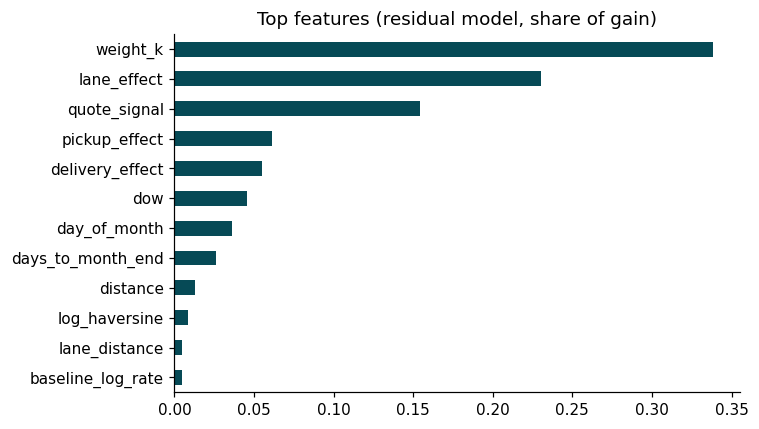

In [19]:
imp = pd.Series(models[0].booster_.feature_importance("gain"), X_train.columns)   # how much each feature helped
imp = (imp / imp.sum()).sort_values().tail(12)                            # share of total gain, top 12
ax = imp.plot.barh(figsize=(7, 4), color="#064A56"); ax.set_title("Top features (residual model, share of gain)")
plt.tight_layout(); plt.savefig(FIG / "feature_importance.png"); plt.show()

## 9. Predictions
**Why:** the answer file must have exactly `load_id,predicted_rate`, all 12,000 ids, in the template's order, with
positive numbers. We merge on `load_id` (not on row position) so order mistakes cannot happen.

In [20]:
pred_df = pd.DataFrame({"load_id": val["load_id"], "predicted_rate": val_pred.round(2)})   # our predictions with their ids
out = template[["load_id"]].merge(pred_df, on="load_id", how="left")      # follow the template's id order
assert len(out) == 12_000 and out["predicted_rate"].notna().all() and (out["predicted_rate"] > 0).all()
assert out["load_id"].is_unique                                           # no duplicate ids
out.to_csv("validation_predictions.csv", index=False)                     # the file to submit
print(out.head(3), "\nsaved", out.shape)

# ---- December chart: same load every day, only the date changes ----
dec_in = dec.drop(columns="predicted_rate")                               # features only (the column is still empty)
X_dec = fb.transform(dec_in, market_context=val)                          # this file has no quote_signal -> use the per-date
                                                                          # average from validation.csv (features, not labels)
dec["predicted_rate"] = predict_final(X_dec).round(2)                     # predict the 31 days
dec.to_csv(DATA / "december_chart_inputs.csv", index=False)               # fill the file in place (as README asks)
display(dec[["date", "predicted_rate"]].T)

     load_id  predicted_rate
0  TE-000001          842.64
1  TE-000002         5018.58
2  TE-000003         5164.03 
saved (12000, 2)


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
date,2025-12-01,2025-12-02,2025-12-03,2025-12-04,2025-12-05,2025-12-06,2025-12-07,2025-12-08,2025-12-09,2025-12-10,...,2025-12-22,2025-12-23,2025-12-24,2025-12-25,2025-12-26,2025-12-27,2025-12-28,2025-12-29,2025-12-30,2025-12-31
predicted_rate,799.8,805.53,809.82,809.81,809.82,802.41,800.53,800.5,807.04,812.24,...,807.46,811.2,817.36,817.36,817.6,807.92,809.93,811.14,814.7,816.97


## 10. Sanity checks (does the output look like freight?)
**Why:** metrics on Jan–Oct can't tell us if Nov–Dec output is sensible. We check (a) the predicted rate-per-mile is in
the historical range, (b) the December chart sits near what that lane actually paid, (c) which inputs *shifted* between
train and validation. (This check caught a real bug: my first fallback for unseen-lane distances gave absurd values
for some city pairs, so unseen lanes now simply trust the load's own reported distance.)

In [21]:
vp = val.assign(pred=val_pred, rpm=val_pred / val["distance"])            # validation rows with predicted rate/mile
print("Predicted rate/mile by month (validation):\n", vp.groupby(vp["date"].dt.to_period("M"))["rpm"].median().round(3))
print("Actual median rate/mile Sep & Oct (train):\n", eda[eda["date"] >= "2025-09-01"].groupby(eda["date"].dt.to_period("M"))["rpm"].median().round(3))

lane = train_clean[(train_clean["pickup"] == "Lexington") & (train_clean["delivery"] == "Fort Wayne")   # the chart's lane ...
                   & (train_clean["equipment"] == "Dry Van")]                                              # ... and equipment
lane_m = (lane["posted_rate"] / lane["distance"] * 360).groupby(lane["date"].dt.to_period("M")).median()   # scaled to 360 miles
print("\nHistorical Lexington->Fort Wayne Dry Van, rate scaled to 360 mi:\n", lane_m.round(0).to_dict())
print("December prediction range: $%.0f - $%.0f" % (dec["predicted_rate"].min(), dec["predicted_rate"].max()))

smd = ((X_val.mean() - X_train.mean()) / X_train.std()).abs().sort_values(ascending=False)   # standardized mean shift per feature
print("\nLargest train->validation feature shifts (in std-devs):\n", smd.head(6).round(3))

Predicted rate/mile by month (validation):
 date
2025-11    2.147
2025-12    2.148
Freq: M, Name: rpm, dtype: float64
Actual median rate/mile Sep & Oct (train):
 date
2025-09    2.160
2025-10    2.164
Freq: M, Name: rpm, dtype: float64

Historical Lexington->Fort Wayne Dry Van, rate scaled to 360 mi:
 {Period('2025-01', 'M'): 778.0, Period('2025-02', 'M'): 817.0, Period('2025-03', 'M'): 792.0, Period('2025-04', 'M'): 833.0, Period('2025-05', 'M'): 877.0, Period('2025-06', 'M'): 825.0, Period('2025-07', 'M'): 875.0, Period('2025-08', 'M'): 795.0, Period('2025-09', 'M'): 798.0, Period('2025-10', 'M'): 816.0}
December prediction range: $800 - $818

Largest train->validation feature shifts (in std-devs):
 near_holiday      0.320
weight_missing    0.095
quote_signal      0.039
is_weekend        0.031
weight_k          0.017
pickup_lat        0.017
dtype: float64


## 11. Run the official scorer
**Why:** `score.py` checks the two files (format, 12,000 ids, positive values, the 31 fixed December rows) and draws
the December chart that goes in the report. Spotter computes the real accuracy afterwards.

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
 


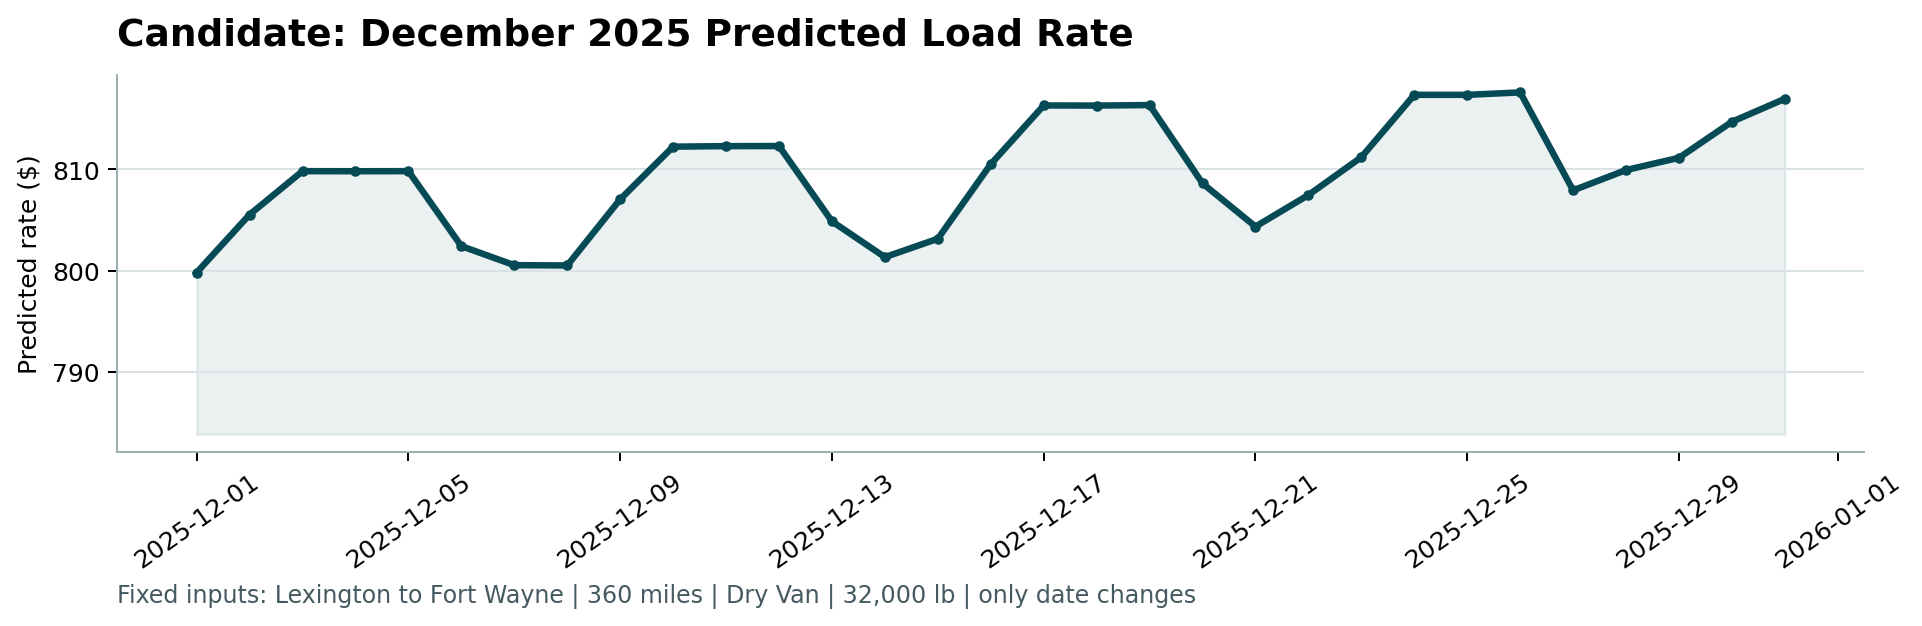

In [22]:
r = subprocess.run([sys.executable, "score.py", "--predictions", "validation_predictions.csv",
                    "--december-predictions", "data/december_chart_inputs.csv"], capture_output=True, text=True)
print(r.stdout, r.stderr)                                                 # should end with "Created chart: ..."
display(Image("scorer_results/candidate_december.png"))                   # show the chart

## Summary & honest limitations
* **Split:** expanding-window, time-based; random split shown to be over-optimistic.
* **Cleaning:** negative weights → `abs()`, missing weight/market_index → train-learned fills + flags, label outliers
  (about 1.4%) dropped from *train only*; nothing dropped from validation.
* **Model:** linear log-distance×equipment baseline + LightGBM on its residual (5-seed average).
* **Limitations:** Nov–Dec are months with no training history, so any seasonal change in the market level cannot be
  learned (month features were deliberately excluded and `market_index` did not transfer across time). Raw error is
  dominated by noisy labels that no model can predict; the "clean" numbers show model quality without them.

In [23]:
import os, pandas as pd
print("working folder:", os.getcwd())
print(os.path.exists("validation_predictions.csv"), os.path.exists("data/december_chart_inputs.csv"))

p = pd.read_csv("validation_predictions.csv")
print(p.shape, "| missing:", p["predicted_rate"].isna().sum())
print(p.head())

d = pd.read_csv("data/december_chart_inputs.csv")
print(d["predicted_rate"].notna().sum(), "of 31 December rows filled")

working folder: /content/freight-rate-challenge
True True
(12000, 2) | missing: 0
     load_id  predicted_rate
0  TE-000001          842.64
1  TE-000002         5018.58
2  TE-000003         5164.03
3  TE-000004         4028.55
4  TE-000005         1856.88
31 of 31 December rows filled


In [25]:
from google.colab import files
files.download("data/december_chart_inputs.csv")
files.download("scorer_results/candidate_december.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>